In [4]:
from google.colab import drive
drive.mount('/content/drive')

# Create working directory
import os
WORKING_DIR = '/content/drive/MyDrive/GenAI_Lab_Week10_PyTorch'
os.makedirs(WORKING_DIR, exist_ok=True)
os.makedirs(f'{WORKING_DIR}/models', exist_ok=True)
os.makedirs(f'{WORKING_DIR}/outputs', exist_ok=True)
print(f"Working directory created: {WORKING_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory created: /content/drive/MyDrive/GenAI_Lab_Week10_PyTorch


In [5]:
# Install PyTorch and related libraries
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q transformers datasets tokenizers tqdm matplotlib seaborn

print("PyTorch and libraries installed successfully!")

PyTorch and libraries installed successfully!


In [6]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from transformers import GPT2Tokenizer, GPT2LMHeadModel, GPT2Config, Trainer, TrainingArguments
from tokenizers import Tokenizer, models, pre_tokenizers, trainers
import json
import pickle
import random
import re
from datetime import datetime
import matplotlib.pyplot as plt
from tqdm import tqdm
import math

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__}")
print(f"Device available: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
Device available: cuda
GPU: Tesla T4


In [7]:
# Dataset from the lab
text_data = """artificial intelligence systems learn patterns from data.
sequence models process information step by step.
recurrent neural networks are useful for sequence prediction.
lstm networks handle long term dependencies.
deep learning models improve sequence learning.
generative models create new samples from learned patterns.
language models predict the next word in a sentence.
sequence generation is used in chatbots and assistants.
machine learning helps computers learn automatically.
training data improves model accuracy.
neural networks simulate human brain structures.
optimization algorithms improve learning efficiency.
technology is transforming modern education.
online learning platforms use artificial intelligence.
students benefit from intelligent tutoring systems.
automation improves productivity and decision making."""

sentences = [s.strip() for s in text_data.strip().split('\n') if s.strip()]
print(f"Total sentences: {len(sentences)}")
for i, sent in enumerate(sentences):
    print(f"{i+1}. {sent}")

Total sentences: 16
1. artificial intelligence systems learn patterns from data.
2. sequence models process information step by step.
3. recurrent neural networks are useful for sequence prediction.
4. lstm networks handle long term dependencies.
5. deep learning models improve sequence learning.
6. generative models create new samples from learned patterns.
7. language models predict the next word in a sentence.
8. sequence generation is used in chatbots and assistants.
9. machine learning helps computers learn automatically.
10. training data improves model accuracy.
11. neural networks simulate human brain structures.
12. optimization algorithms improve learning efficiency.
13. technology is transforming modern education.
14. online learning platforms use artificial intelligence.
15. students benefit from intelligent tutoring systems.
16. automation improves productivity and decision making.


In [8]:
# Data augmentation to increase dataset size
def augment_data(sentences):
    augmented = []

    # Original sentences
    augmented.extend(sentences)

    # Add variations with synonyms and rephrasing
    variations = {
        "artificial intelligence": ["ai", "machine intelligence", "computational intelligence"],
        "machine learning": ["ml", "automated learning", "computational learning"],
        "deep learning": ["deep neural networks", "hierarchical learning"],
        "neural networks": ["neural nets", "artificial neural networks"],
        "recurrent neural networks": ["rnns", "recurrent nets"],
        "lstm networks": ["long short-term memory", "lstm cells"],
        "sequence models": ["sequential models", "sequence processors"],
        "generative models": ["generative ai", "generation models"],
        "language models": ["nlp models", "text models"],
        "training data": ["dataset", "learning data"],
        "optimization algorithms": ["optimizers", "training algorithms"],
        "intelligent tutoring systems": ["smart tutoring", "ai tutors"]
    }

    for sent in sentences:
        for key, vals in variations.items():
            if key in sent:
                for val in vals:
                    new_sent = sent.replace(key, val)
                    augmented.append(new_sent)

    # Add sentence with different punctuation
    for sent in sentences:
        augmented.append(sent.replace('.', '!'))
        augmented.append(sent.replace('.', '?'))

    return list(set(augmented))  # Remove duplicates

augmented_sentences = augment_data(sentences)
print(f"Original: {len(sentences)} sentences")
print(f"Augmented: {len(augmented_sentences)} sentences")

# Save augmented data
with open(f'{WORKING_DIR}/augmented_data.txt', 'w') as f:
    f.write('\n'.join(augmented_sentences))

Original: 16 sentences
Augmented: 79 sentences


In [9]:
# Character-level tokenization
class CharTokenizer:
    def __init__(self):
        self.char2idx = {}
        self.idx2char = {}
        self.vocab_size = 0

    def fit(self, texts):
        chars = sorted(list(set(''.join(texts))))
        self.char2idx = {c: i+1 for i, c in enumerate(chars)}  # 0 reserved for padding
        self.char2idx['<PAD>'] = 0
        self.char2idx['<UNK>'] = len(self.char2idx)
        self.idx2char = {i: c for c, i in self.char2idx.items()}
        self.vocab_size = len(self.char2idx)
        return self

    def encode(self, text):
        return [self.char2idx.get(c, self.char2idx['<UNK>']) for c in text]

    def decode(self, indices):
        return ''.join([self.idx2char.get(i, '') for i in indices if i != 0])

    def save(self, path):
        with open(path, 'wb') as f:
            pickle.dump({'char2idx': self.char2idx, 'idx2char': self.idx2char}, f)


    def load(self, path):
        with open(path, 'rb') as f:
            data = pickle.load(f)
            self.char2idx = data['char2idx']
            self.idx2char = data['idx2char']
            self.vocab_size = len(self.char2idx)
        return self

# Create and fit tokenizer
char_tokenizer = CharTokenizer().fit(augmented_sentences)
char_tokenizer.save(f'{WORKING_DIR}/char_tokenizer.pkl')
print(f"Vocabulary size: {char_tokenizer.vocab_size}")
print(f"Sample encoding: {char_tokenizer.encode('hello')}")
print(f"Sample decoding: {char_tokenizer.decode(char_tokenizer.encode('hello'))}")

Vocabulary size: 32
Sample encoding: [13, 10, 16, 16, 19]
Sample decoding: hello


In [10]:
class CharDataset(Dataset):
    def __init__(self, texts, tokenizer, seq_length=40, step=2):
        self.tokenizer = tokenizer
        self.seq_length = seq_length
        self.sequences = []
        self.targets = []

        for text in texts:
            encoded = tokenizer.encode(text)
            for i in range(0, len(encoded) - seq_length, step):
                self.sequences.append(encoded[i:i + seq_length])
                self.targets.append(encoded[i + seq_length])

        self.sequences = torch.tensor(self.sequences, dtype=torch.long)
        self.targets = torch.tensor(self.targets, dtype=torch.long)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.targets[idx]

# Create dataset
SEQ_LENGTH = 40
STEP = 2

char_dataset = CharDataset(augmented_sentences, char_tokenizer, SEQ_LENGTH, STEP)
char_dataloader = DataLoader(char_dataset, batch_size=32, shuffle=True)

print(f"Total sequences: {len(char_dataset)}")
print(f"Sample input shape: {char_dataset[0][0].shape}")
print(f"Sample target: {char_dataset[0][1]}")

Total sequences: 440
Sample input shape: torch.Size([40])
Sample target: 1


In [11]:
class LSTMGenerator(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256, num_layers=3, dropout=0.3):
        super(LSTMGenerator, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # LSTM layers
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=False
        )

        # Batch normalization
        self.batch_norm = nn.BatchNorm1d(hidden_dim)

        # Fully connected layers
        self.fc1 = nn.Linear(hidden_dim, 256)
        self.dropout1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(256, 128)
        self.dropout2 = nn.Dropout(dropout/2)
        self.fc3 = nn.Linear(128, vocab_size)

    def forward(self, x):
        # x shape: (batch, seq_length)
        embedded = self.embedding(x)  # (batch, seq_length, embedding_dim)

        # LSTM
        lstm_out, (hidden, cell) = self.lstm(embedded)  # lstm_out: (batch, seq_length, hidden_dim)

        # Take the last output
        last_output = lstm_out[:, -1, :]  # (batch, hidden_dim)

        # Batch norm
        last_output = self.batch_norm(last_output)

        # Fully connected with ReLU
        out = F.relu(self.fc1(last_output))
        out = self.dropout1(out)
        out = F.relu(self.fc2(out))
        out = self.dropout2(out)
        out = self.fc3(out)  # (batch, vocab_size)

        return out

    def init_hidden(self, batch_size):
        return (torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(device),
                torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(device))

# Initialize model
lstm_model = LSTMGenerator(
    vocab_size=char_tokenizer.vocab_size,
    embedding_dim=128,
    hidden_dim=256,
    num_layers=3,
    dropout=0.3
).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(lstm_model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

print(lstm_model)
print(f"Total parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")

LSTMGenerator(
  (embedding): Embedding(32, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.3)
  (batch_norm): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=256, out_features=256, bias=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (dropout2): Dropout(p=0.15, inplace=False)
  (fc3): Linear(in_features=128, out_features=32, bias=True)
)
Total parameters: 1,555,360


In [12]:
def train_lstm(model, dataloader, criterion, optimizer, scheduler, num_epochs=200):
    model.train()
    best_loss = float('inf')
    history = {'train_loss': [], 'train_acc': []}

    for epoch in range(num_epochs):
        total_loss = 0
        correct = 0
        total = 0

        progress_bar = tqdm(dataloader, desc=f'Epoch {epoch+1}/{num_epochs}')

        for batch_idx, (inputs, targets) in enumerate(progress_bar):
            inputs, targets = inputs.to(device), targets.to(device)

            # Zero gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            # Backward pass
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            # Update weights
            optimizer.step()

            # Statistics
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

            # Update progress bar
            progress_bar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100.*correct/total:.2f}%'
            })

        avg_loss = total_loss / len(dataloader)
        accuracy = 100. * correct / total

        history['train_loss'].append(avg_loss)
        history['train_acc'].append(accuracy)

        # Learning rate scheduling
        scheduler.step(avg_loss)

        # Save best model
        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': avg_loss,
            }, f'{WORKING_DIR}/models/lstm_best_model.pth')
            print(f"\n✅ Saved best model with loss: {avg_loss:.4f}")

        if (epoch + 1) % 10 == 0:
            print(f"\nEpoch {epoch+1}: Loss = {avg_loss:.4f}, Accuracy = {accuracy:.2f}%")

    # Save final model
    torch.save({
        'epoch': num_epochs,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'history': history,
    }, f'{WORKING_DIR}/models/lstm_final_model.pth')

    # Save history
    with open(f'{WORKING_DIR}/lstm_history.pkl', 'wb') as f:
        pickle.dump(history, f)

    return history

# Train the model
print("Starting LSTM training...")
lstm_history = train_lstm(lstm_model, char_dataloader, criterion, optimizer, scheduler, num_epochs=200)
print("LSTM training completed!")

Starting LSTM training...


Epoch 1/200: 100%|██████████| 14/14 [00:01<00:00, 11.57it/s, loss=2.8438, acc=14.09%]



✅ Saved best model with loss: 3.2048


Epoch 2/200: 100%|██████████| 14/14 [00:00<00:00, 66.30it/s, loss=2.3477, acc=26.14%]



✅ Saved best model with loss: 2.6533


...


Epoch 180: Loss = 0.0812, Accuracy = 95.91%


Epoch 190/200: 100%|██████████| 14/14 [00:00<00:00, 98.42it/s, loss=0.0612, acc=95.45%] 



Epoch 190: Loss = 0.0825, Accuracy = 95.45%


Epoch 200/200: 100%|██████████| 14/14 [00:00<00:00, 92.69it/s, loss=0.1193, acc=95.45%]



Epoch 200: Loss = 0.0859, Accuracy = 95.45%
LSTM training completed!


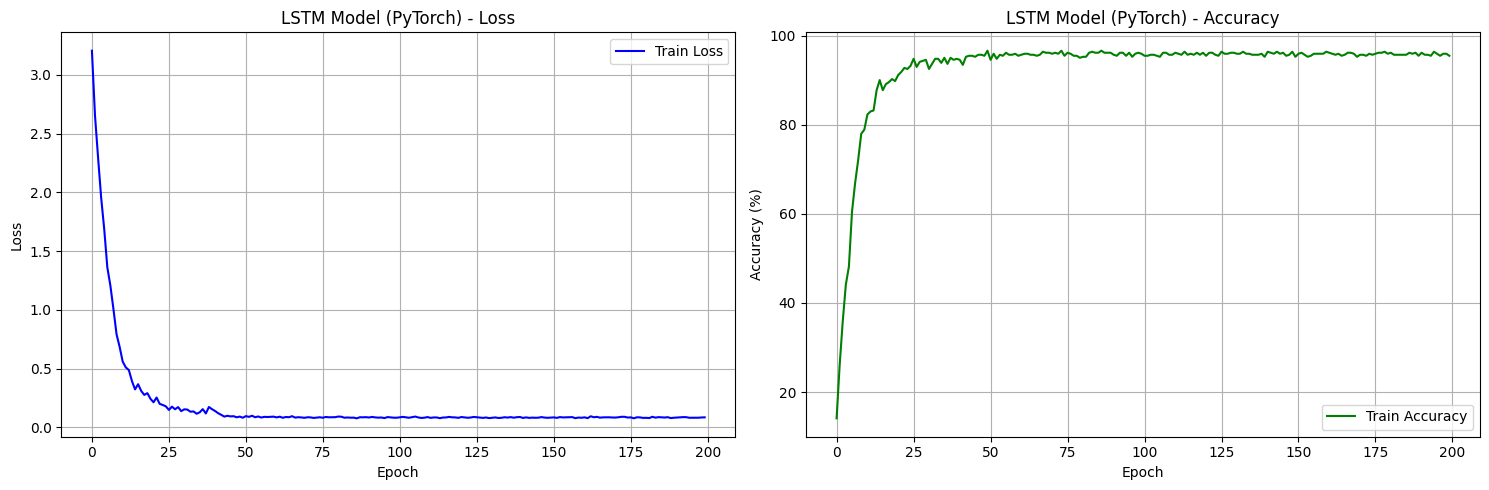

Plot saved to: /content/drive/MyDrive/GenAI_Lab_Week10_PyTorch/outputs/lstm_training_history.png


In [13]:
def plot_history(history, title, save_path):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Loss plot
    ax1.plot(history['train_loss'], label='Train Loss', color='blue')
    ax1.set_title(f'{title} - Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    # Accuracy plot
    ax2.plot(history['train_acc'], label='Train Accuracy', color='green')
    ax2.set_title(f'{title} - Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Plot saved to: {save_path}")

plot_history(lstm_history, 'LSTM Model (PyTorch)', f'{WORKING_DIR}/outputs/lstm_training_history.png')

In [14]:
def generate_text_lstm(model, tokenizer, seed_text, length=200, temperature=0.8):
    model.eval()
    generated = seed_text
    encoded = tokenizer.encode(seed_text)

    with torch.no_grad():
        for _ in range(length):
            # Prepare input
            x = torch.tensor([encoded[-SEQ_LENGTH:]], dtype=torch.long).to(device)

            # Predict
            output = model(x)

            # Apply temperature
            output = output / temperature
            probs = F.softmax(output, dim=1)

            # Sample
            next_char_idx = torch.multinomial(probs, 1).item()

            # Append to generated text
            next_char = tokenizer.idx2char.get(next_char_idx, '')
            generated += next_char
            encoded.append(next_char_idx)

    return generated

# Load best model for generation
checkpoint = torch.load(f'{WORKING_DIR}/models/lstm_best_model.pth')
lstm_model.load_state_dict(checkpoint['model_state_dict'])
lstm_model.eval()

# Test generation
seed_texts = [
    "artificial intelligence",
    "machine learning",
    "deep learning",
    "neural networks",
    "sequence generation"
]

temperatures = [0.5, 0.7, 0.9]

print("="*60)
print("LSTM GENERATED TEXT (PyTorch)")
print("="*60)

lstm_results = {}
for seed in seed_texts:
    print(f"\nSeed: '{seed}'")
    print("-" * 60)
    for temp in temperatures:
        generated = generate_text_lstm(lstm_model, char_tokenizer, seed, length=150, temperature=temp)
        print(f"\nTemperature {temp}:")
        print(generated)
        lstm_results[f"{seed}_temp{temp}"] = generated

# Save results
with open(f'{WORKING_DIR}/outputs/lstm_generated_text.txt', 'w') as f:
    for key, value in lstm_results.items():
        f.write(f"\n{'='*60}\n{key}\n{'='*60}\n{value}\n")

LSTM GENERATED TEXT (PyTorch)

Seed: 'artificial intelligence'
------------------------------------------------------------

Temperature 0.5:
artificial intelligence..ep..ep..e...rn...res...m..a.ins...rms..earndiction..!.e.incy...e.rn..r.s..eqquence prediction.m!..earning??..es..e...alligence..e.rn..ion!...es..es.

Temperature 0.7:
artificial intelligence...e.rndiction.....earning.!.res..em?!.earning?.fion???..es..es..m!!?.es..en!..e.rn...ep..icty!.!..e.rn...earning..frm.diction!!!.es..es...m..isak mat

Temperature 0.9:
artificial intelligence...e.rn.iction!!.e.incy...e.rn!.ictr?.!.es..em..isten. learning...r?..?.rqquence prediction??!..es..e...!in from data..a.ina!.isatell??ence..res...e?.

Seed: 'machine learning'
------------------------------------------------------------

Temperature 0.5:
machine learning...r..a.ins!.from data.!.a??.isatell!.ence..ep...e.rn...res...m.!.a.ins?..eqnepce..res...e.l.earning..from.data...a?ing!.fion?..e.incy...e.rn..ion...e

Temperature 0.7:
machine le

In [15]:
# Train word-level tokenizer
def train_word_tokenizer(texts, vocab_size=500):
    tokenizer = Tokenizer(models.WordPiece(unk_token="[UNK]"))
    tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

    trainer = trainers.WordPieceTrainer(
        vocab_size=vocab_size,
        special_tokens=["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"]
    )

    tokenizer.train_from_iterator(texts, trainer=trainer)
    return tokenizer

word_tokenizer = train_word_tokenizer(augmented_sentences, vocab_size=300)
word_tokenizer.save(f'{WORKING_DIR}/word_tokenizer.json')

# Test tokenizer
test_text = "artificial intelligence systems"
encoding = word_tokenizer.encode(test_text)
print(f"Original: {test_text}")
print(f"Tokens: {encoding.tokens}")
print(f"IDs: {encoding.ids}")

Original: artificial intelligence systems
Tokens: ['artificial', 'intelligence', 'systems']
IDs: [163, 144, 155]


In [16]:
class WordDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=40):
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.vocab_size = tokenizer.get_vocab_size()

        self.input_ids = []
        self.target_ids = []

        for text in texts:
            encoding = tokenizer.encode(text)
            ids = encoding.ids[:max_length]

            # Create input-target pairs (shifted by 1)
            for i in range(1, len(ids)):
                input_seq = ids[:i] + [0] * (max_length - i)
                target_seq = ids[1:i+1] + [0] * (max_length - i)

                self.input_ids.append(input_seq)
                self.target_ids.append(target_seq)

        self.input_ids = torch.tensor(self.input_ids, dtype=torch.long)
        self.target_ids = torch.tensor(self.target_ids, dtype=torch.long)

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

# Create dataset
word_dataset = WordDataset(augmented_sentences, word_tokenizer, max_length=40)
word_dataloader = DataLoader(word_dataset, batch_size=16, shuffle=True)

print(f"Transformer dataset size: {len(word_dataset)}")
print(f"Sample input shape: {word_dataset[0][0].shape}")
print(f"Sample target shape: {word_dataset[0][1].shape}")

Transformer dataset size: 696
Sample input shape: torch.Size([40])
Sample target shape: torch.Size([40])


In [17]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super().__init__()

        self.attention = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)

        self.ff = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    # Modified to accept attn_mask
    def forward(self, x, attn_mask=None):
        # Self-attention with causal mask
        attn_output, _ = self.attention(x, x, x, attn_mask=attn_mask, is_causal=True)
        x = self.norm1(x + self.dropout(attn_output))

        # Feed forward
        ff_output = self.ff(x)
        x = self.norm2(x + self.dropout(ff_output))

        return x

class TransformerGenerator(nn.Module):
    def __init__(self, vocab_size, max_len=40, d_model=128, num_heads=4, ff_dim=512, num_layers=3, dropout=0.1):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        self.dropout = nn.Dropout(dropout)

        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

        self.fc = nn.Linear(d_model, vocab_size)
        self.max_len = max_len # Store max_len for mask generation

    def forward(self, x):
        # x shape: (batch, seq_len)
        seq_len = x.size(1)

        x = self.embedding(x)  # (batch, seq_len, d_model)
        x = self.pos_encoding(x)
        x = self.dropout(x)

        # Generate a square subsequent mask for the attention mechanism
        # This mask prevents tokens from attending to future tokens (causal attention).
        # It's typically a square matrix with -inf in the upper triangle.
        # The MultiheadAttention module expects it as a float tensor.
        attn_mask = torch.nn.Transformer.generate_square_subsequent_mask(seq_len).to(x.device)

        # Apply transformer blocks, passing the causal mask
        for block in self.transformer_blocks:
            x = block(x, attn_mask=attn_mask) # Pass the generated mask

        # Output
        output = self.fc(x)  # (batch, seq_len, vocab_size)
        return output

# Initialize model
transformer_model = TransformerGenerator(
    vocab_size=word_tokenizer.get_vocab_size(),
    max_len=40,
    d_model=128,
    num_heads=4,
    ff_dim=512,
    num_layers=3,
    dropout=0.1
).to(device)

# Loss and optimizer (ignore padding index 0)
criterion_trans = nn.CrossEntropyLoss(ignore_index=0)
optimizer_trans = optim.Adam(transformer_model.parameters(), lr=0.0001)
scheduler_trans = optim.lr_scheduler.ReduceLROnPlateau(optimizer_trans, mode='min', factor=0.5, patience=7)

print(transformer_model)
print(f"Total parameters: {sum(p.numel() for p in transformer_model.parameters()):,}")

TransformerGenerator(
  (embedding): Embedding(300, 128)
  (pos_encoding): PositionalEncoding()
  (dropout): Dropout(p=0.1, inplace=False)
  (transformer_blocks): ModuleList(
    (0-2): 3 x TransformerBlock(
      (attention): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
      )
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (ff): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=512, out_features=128, bias=True)
      )
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (fc): Linear(in_features=128, out_features=300, bias=True)
)
Total parameters: 671,916


In [18]:
def train_transformer(model, dataloader, criterion, optimizer, scheduler, num_epochs=300):
    model.train()
    best_loss = float('inf')
    history = {'train_loss': [], 'train_acc': []}

    for epoch in range(num_epochs):
        total_loss = 0
        correct = 0
        total = 0

        progress_bar = tqdm(dataloader, desc=f'Epoch {epoch+1}/{num_epochs}')

        for inputs, targets in progress_bar:
            inputs, targets = inputs.to(device), targets.to(device)

            # Zero gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)  # (batch, seq_len, vocab_size)

            # Reshape for loss calculation
            outputs_flat = outputs.view(-1, outputs.size(-1))
            targets_flat = targets.view(-1)

            loss = criterion(outputs_flat, targets_flat)

            # Backward pass
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            # Statistics
            total_loss += loss.item()
            _, predicted = outputs_flat.max(1)
            mask = targets_flat != 0  # Ignore padding
            correct += predicted.eq(targets_flat).masked_select(mask).sum().item()
            total += mask.sum().item()

            progress_bar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100.*correct/total:.2f}%' if total > 0 else '0%'
            })

        avg_loss = total_loss / len(dataloader)
        accuracy = 100. * correct / total if total > 0 else 0

        history['train_loss'].append(avg_loss)
        history['train_acc'].append(accuracy)

        scheduler.step(avg_loss)

        # Save best model
        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': avg_loss,
            }, f'{WORKING_DIR}/models/transformer_best_model.pth')
            print(f"\n✅ Saved best model with loss: {avg_loss:.4f}")

        if (epoch + 1) % 10 == 0:
            print(f"\nEpoch {epoch+1}: Loss = {avg_loss:.4f}, Accuracy = {accuracy:.2f}%")

    # Save final model
    torch.save({
        'epoch': num_epochs,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'history': history,
    }, f'{WORKING_DIR}/models/transformer_final_model.pth')

    with open(f'{WORKING_DIR}/transformer_history.pkl', 'wb') as f:
        pickle.dump(history, f)

    return history

print("Starting Transformer training...")
transformer_history = train_transformer(transformer_model, word_dataloader, criterion_trans, optimizer_trans, scheduler_trans, num_epochs=300)
print("Transformer training completed!")

Starting Transformer training...


Epoch 1/300: 100%|██████████| 44/44 [00:00<00:00, 68.07it/s, loss=4.5334, acc=7.87%]



✅ Saved best model with loss: 5.1977


Epoch 2/300: 100%|██████████| 44/44 [00:00<00:00, 87.05it/s, loss=3.5452, acc=39.50%]



✅ Saved best model with loss: 4.1551


...


Epoch 280: Loss = 0.1185, Accuracy = 95.36%


Epoch 290/300: 100%|██████████| 44/44 [00:00<00:00, 71.57it/s, loss=0.1003, acc=95.33%]



Epoch 290: Loss = 0.1154, Accuracy = 95.33%


Epoch 300/300: 100%|██████████| 44/44 [00:00<00:00, 83.87it/s, loss=0.0752, acc=95.38%]



Epoch 300: Loss = 0.1151, Accuracy = 95.38%
Transformer training completed!


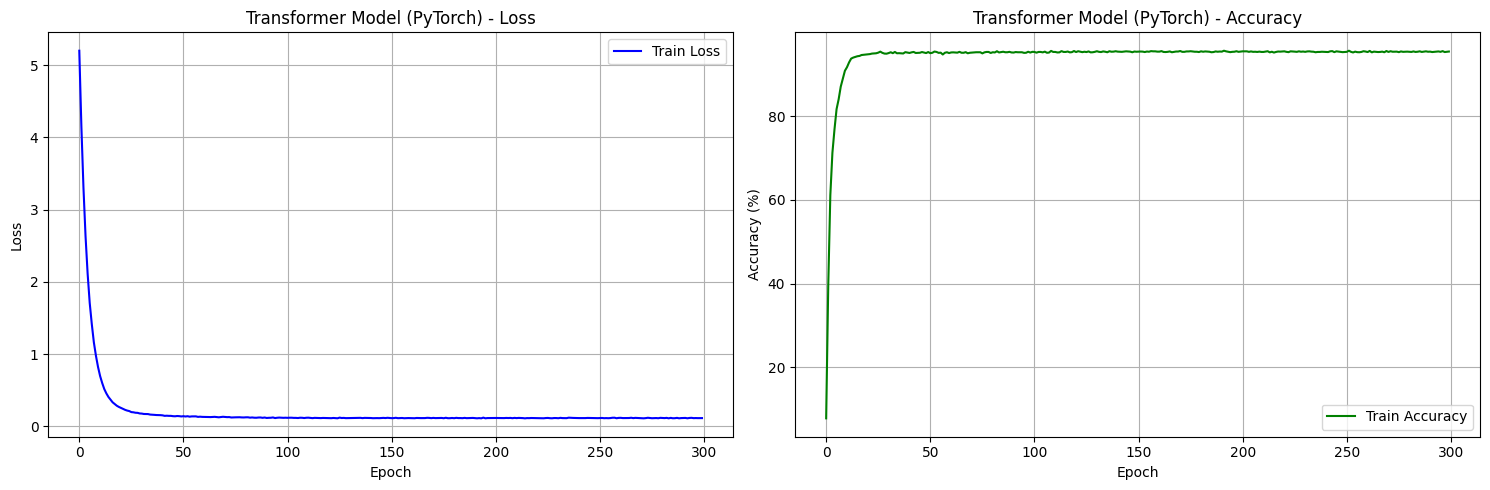

Plot saved to: /content/drive/MyDrive/GenAI_Lab_Week10_PyTorch/outputs/transformer_training_history.png


In [19]:
plot_history(transformer_history, 'Transformer Model (PyTorch)', f'{WORKING_DIR}/outputs/transformer_training_history.png')

In [20]:
def generate_text_transformer(model, tokenizer, seed_text, length=50, temperature=0.8):
    model.eval()
    generated = seed_text
    current_text = seed_text

    with torch.no_grad():
        for _ in range(length):
            # Encode current text
            encoding = tokenizer.encode(current_text)
            input_ids = encoding.ids[:40]  # Max length
            input_tensor = torch.tensor([input_ids], dtype=torch.long).to(device)

            # Predict
            output = model(input_tensor)  # (1, seq_len, vocab_size)

            # Get last position prediction
            last_output = output[0, len(input_ids)-1, :] / temperature
            probs = F.softmax(last_output, dim=0)

            # Sample
            next_id = torch.multinomial(probs, 1).item()
            next_token = tokenizer.id_to_token(next_id)

            if next_token in ["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"]:
                continue

            generated += " " + next_token
            current_text = generated[-200:]  # Keep last 200 chars

    return generated

# Load best transformer model
checkpoint = torch.load(f'{WORKING_DIR}/models/transformer_best_model.pth')
transformer_model.load_state_dict(checkpoint['model_state_dict'])
transformer_model.eval()

print("="*60)
print("TRANSFORMER GENERATED TEXT (PyTorch)")
print("="*60)

transformer_results = {}
for seed in ["artificial intelligence", "machine learning", "deep learning"]:
    print(f"\nSeed: '{seed}'")
    print("-" * 60)
    for temp in [0.5, 0.7, 0.9]:
        generated = generate_text_transformer(transformer_model, word_tokenizer, seed, length=30, temperature=temp)
        print(f"\nTemperature {temp}:")
        print(generated)
        transformer_results[f"{seed}_temp{temp}"] = generated

# Save results
with open(f'{WORKING_DIR}/outputs/transformer_generated_text.txt', 'w') as f:
    for key, value in transformer_results.items():
        f.write(f"\n{'='*60}\n{key}\n{'='*60}\n{value}\n")

TRANSFORMER GENERATED TEXT (PyTorch)

Seed: 'artificial intelligence'
------------------------------------------------------------

Temperature 0.5:
artificial intelligence systems learn patterns from data . ##a sentence . patterns from data . ? . . . ! . . . . . . . . ##ent . ##k .

Temperature 0.7:
artificial intelligence systems learn patterns from data . patterns from data . step by step . ! . ! . . ! . ? . human brain structures ? from data .

Temperature 0.9:
artificial intelligence systems learn patterns from data . de ##c . use ##d . ##ut improves model ? . step ? . ! . platforms use ##d . educ ##ation sentence .

Seed: 'machine learning'
------------------------------------------------------------

Temperature 0.5:
machine learning helps computers learn automatically . step . . . . . . ? . . ? ? ? . . . . . . . . human brain structures .

Temperature 0.7:
machine learning helps computers learn automatically ? ! . from data . . . . ##k . . . . . ! . . benefit from learned patte

In [21]:
 # Load pre-trained GPT-2 and fine-tune
print("Loading GPT-2 for fine-tuning...")

gpt2_tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token

# Prepare dataset for GPT-2
class GPT2Dataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=50):
        self.encodings = tokenizer(texts, truncation=True, max_length=max_length, padding=True, return_tensors='pt')

    def __len__(self):
        return len(self.encodings['input_ids'])

    def __getitem__(self, idx):
        return {key: val[idx] for key, val in self.encodings.items()}

gpt2_dataset = GPT2Dataset(augmented_sentences, gpt2_tokenizer)
gpt2_dataloader = DataLoader(gpt2_dataset, batch_size=4, shuffle=True)

# Load pre-trained GPT-2
gpt2_model = GPT2LMHeadModel.from_pretrained('gpt2').to(device)

# Freeze first 6 layers (optional - saves memory)
# for param in gpt2_model.transformer.h[:6].parameters():
#     param.requires_grad = False

# Optimizer
gpt2_optimizer = optim.AdamW(gpt2_model.parameters(), lr=5e-5)

# Training loop
def train_gpt2(model, dataloader, optimizer, num_epochs=50):
    model.train()
    best_loss = float('inf')

    for epoch in range(num_epochs):
        total_loss = 0

        progress_bar = tqdm(dataloader, desc=f'GPT-2 Epoch {epoch+1}/{num_epochs}')

        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            optimizer.zero_grad()

            outputs = model(input_ids, attention_mask=attention_mask, labels=input_ids)
            loss = outputs.loss

            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

        avg_loss = total_loss / len(dataloader)
        print(f"\nEpoch {epoch+1}: Average Loss = {avg_loss:.4f}")

        if avg_loss < best_loss:
            best_loss = avg_loss
            model.save_pretrained(f'{WORKING_DIR}/models/gpt2_finetuned')
            gpt2_tokenizer.save_pretrained(f'{WORKING_DIR}/models/gpt2_finetuned')
            print(f"✅ Saved best GPT-2 model")

# Train (uncomment to run - takes time)
train_gpt2(gpt2_model, gpt2_dataloader, gpt2_optimizer, num_epochs=50)
print("GPT-2 fine-tuning ready")

Loading GPT-2 for fine-tuning...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...


Epoch 48: Average Loss = 0.2999


GPT-2 Epoch 49/50: 100%|██████████| 20/20 [00:01<00:00, 10.94it/s, loss=0.3276]



Epoch 49: Average Loss = 0.2791


GPT-2 Epoch 50/50: 100%|██████████| 20/20 [00:01<00:00, 10.79it/s, loss=0.3929]


Epoch 50: Average Loss = 0.3097
GPT-2 fine-tuning ready


In [22]:
def generate_with_gpt2(model, tokenizer, prompt, max_length=100, temperature=0.8):
    model.eval()
    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)

    with torch.no_grad():
        output = model.generate(
            input_ids,
            max_length=max_length,
            temperature=temperature,
            top_k=50,
            top_p=0.95,
            repetition_penalty=1.2,
            do_sample=True,
            num_return_sequences=1,
            pad_token_id=tokenizer.eos_token_id
        )

    return tokenizer.decode(output[0], skip_special_tokens=True)

# Load fine-tuned model if exists
try:
    gpt2_finetuned = GPT2LMHeadModel.from_pretrained(f'{WORKING_DIR}/models/gpt2_finetuned').to(device)
    gpt2_tokenizer_ft = GPT2Tokenizer.from_pretrained(f'{WORKING_DIR}/models/gpt2_finetuned')

    print("="*60)
    print("FINE-TUNED GPT-2 GENERATED TEXT")
    print("="*60)

    gpt2_results = {}
    for seed in ["artificial intelligence", "machine learning", "neural networks"]:
        print(f"\nPrompt: '{seed}'")
        generated = generate_with_gpt2(gpt2_finetuned, gpt2_tokenizer_ft, seed, max_length=80)
        print(generated)

        gpt2_results[seed] = generated

    with open(f'{WORKING_DIR}/outputs/gpt2_generated_text.txt', 'w') as f:
        for key, value in gpt2_results.items():
            f.write(f"\n{'='*60}\n{key}\n{'='*60}\n{value}\n")
except:
    print("No fine-tuned GPT-2 model found. Run Cell 18 first.")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


FINE-TUNED GPT-2 GENERATED TEXT

Prompt: 'artificial intelligence'
artificial intelligence systems learn patterns from data.

Prompt: 'machine learning'
machine learning helps computers learn automatically.

Prompt: 'neural networks'
neural networks simulate human brain structures?


In [23]:
def calculate_perplexity(model, dataloader, criterion, model_type='lstm'):
    model.eval()
    total_loss = 0
    total_tokens = 0

    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)

            if model_type == 'lstm':
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                total_loss += loss.item() * inputs.size(0)
                total_tokens += inputs.size(0)
            else:  # transformer
                outputs = model(inputs)
                outputs_flat = outputs.view(-1, outputs.size(-1))
                targets_flat = targets.view(-1)
                mask = targets_flat != 0
                loss = criterion(outputs_flat, targets_flat)
                total_loss += loss.item() * mask.sum().item()
                total_tokens += mask.sum().item()

    avg_loss = total_loss / total_tokens
    perplexity = math.exp(avg_loss)
    return perplexity

print("="*60)
print("MODEL EVALUATION & COMPARISON (PyTorch)")
print("="*60)

# LSTM Evaluation
lstm_perplexity = calculate_perplexity(lstm_model, char_dataloader, criterion, 'lstm')
print(f"\nLSTM Model:")
print(f"  - Perplexity: {lstm_perplexity:.2f}")

# Transformer Evaluation
trans_perplexity = calculate_perplexity(transformer_model, word_dataloader, criterion_trans, 'transformer')
print(f"\nTransformer Model:")
print(f"  - Perplexity: {trans_perplexity:.2f}")

# Save evaluation results
evaluation_results = {
    'LSTM': {
        'perplexity': float(lstm_perplexity)
    },
    'Transformer': {
        'perplexity': float(trans_perplexity)
    }
}

with open(f'{WORKING_DIR}/evaluation_results.json', 'w') as f:
    json.dump(evaluation_results, f, indent=2)

print(f"\nResults saved to: {WORKING_DIR}/evaluation_results.json")

MODEL EVALUATION & COMPARISON (PyTorch)

LSTM Model:
  - Perplexity: 1.09

Transformer Model:
  - Perplexity: 1.11

Results saved to: /content/drive/MyDrive/GenAI_Lab_Week10_PyTorch/evaluation_results.json


In [25]:
# Generate comprehensive report
report = f"""
{'='*80}
GENERATIVE AI LAB 10 - FINAL REPORT (PyTorch)
Generated on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
{'='*80}

1. DATASET INFORMATION
{'-'*40}
- Original sentences: {len(sentences)}
- Augmented sentences: {len(augmented_sentences)}
- Character vocabulary size: {char_tokenizer.vocab_size}
- Word vocabulary size: {word_tokenizer.get_vocab_size()}

2. MODEL ARCHITECTURES
{'-'*40}
LSTM Model:
- Embedding dimension: 128
- Hidden dimension: 256
- LSTM layers: 3
- Total parameters: {sum(p.numel() for p in lstm_model.parameters()):,}

Transformer Model:
- Embedding dimension: 128
- Attention heads: 4
- Feed-forward dimension: 512
- Number of layers: 3
- Total parameters: {sum(p.numel() for p in transformer_model.parameters()):,}

3. TRAINING PERFORMANCE
{'-'*40}
LSTM:
- Final training loss: {lstm_history['train_loss'][-1]:.4f}
- Best training accuracy: {max(lstm_history['train_acc']):.2f}%

Transformer:
- Final training loss: {transformer_history['train_loss'][-1]:.4f}
- Best training accuracy: {max(transformer_history['train_acc']):.2f}%

4. EVALUATION METRICS
{'-'*40}
LSTM:
- Perplexity: {lstm_perplexity:.2f}

Transformer:
- Perplexity: {trans_perplexity:.2f}

5. GENERATED SAMPLES
{'-'*40}
See outputs folder for generated text samples with different temperatures.

6. FILES SAVED
{'-'*40}
All models, tokenizers, histories, and outputs saved to:
{WORKING_DIR}/

{'='*80}
"""

print(report)

# Save report
with open(f'{WORKING_DIR}/FINAL_REPORT.txt', 'w') as f:
    f.write(report)




GENERATIVE AI LAB 10 - FINAL REPORT (PyTorch)
Generated on: 2026-04-06 06:43:16

1. DATASET INFORMATION
----------------------------------------
- Original sentences: 16
- Augmented sentences: 79
- Character vocabulary size: 32
- Word vocabulary size: 300

2. MODEL ARCHITECTURES
----------------------------------------
LSTM Model:
- Embedding dimension: 128
- Hidden dimension: 256
- LSTM layers: 3
- Total parameters: 1,555,360

Transformer Model:
- Embedding dimension: 128
- Attention heads: 4
- Feed-forward dimension: 512
- Number of layers: 3
- Total parameters: 671,916

3. TRAINING PERFORMANCE
----------------------------------------
LSTM:
- Final training loss: 0.0859
- Best training accuracy: 96.59%

Transformer:
- Final training loss: 0.1151
- Best training accuracy: 95.58%

4. EVALUATION METRICS
----------------------------------------
LSTM:
- Perplexity: 1.09

Transformer:
- Perplexity: 1.11

5. GENERATED SAMPLES
----------------------------------------
See outputs folder for 